In [2]:
import pandas as pd

# Загрузка данных (предполагаем, что файлы находятся в той же директории)
assessments = pd.read_csv('assessments.csv')
student_assessment = pd.read_csv('studentAssessment.csv')
student_registration = pd.read_csv('studentRegistration.csv')
courses =  pd.read_csv('courses.csv')

# 1. Находим все экзамены (Exam)
exams = assessments[assessments['assessment_type'] == 'Exam'][['id_assessment']]

# 2. Соединяем с результатами студентов
exam_results = pd.merge(student_assessment, exams, on='id_assessment')

# 3. Фильтруем успешные сдачи (оценка >= 40)
passed_exams = exam_results[exam_results['score'] >= 40]

# 4. Группируем по студентам и считаем количество успешных экзаменов
students_passed_count = passed_exams.groupby('id_student').size().reset_index(name='passed_count')

# 5. Находим студентов, сдавших только один экзамен
students_passed_one_course = students_passed_count[students_passed_count['passed_count'] == 1]

# 6. Получаем количество таких студентов
num_students_passed_one_course = len(students_passed_one_course)

print(f"Количество студентов, успешно сдавших только один курс: {num_students_passed_one_course}")

Количество студентов, успешно сдавших только один курс: 3802


In [7]:
import pandas as pd

# Загрузка данных (убедитесь, что файлы находятся в правильной директории)
assessments = pd.read_csv('assessments.csv')
student_assessment = pd.read_csv('studentAssessment.csv')
student_registration = pd.read_csv('studentRegistration.csv')

# 1. Фильтруем только экзамены
exams = assessments[assessments['assessment_type'] == 'Exam']

# 2. Соединяем с результатами студентов
exam_results = pd.merge(student_assessment, exams, on='id_assessment')

# 3. Добавляем информацию о регистрации студентов
exam_results = pd.merge(exam_results, 
                       student_registration,
                       on=['code_module', 'code_presentation', 'id_student'])

# 4. Рассчитываем процент успешной сдачи для каждого экзамена
# Успешная сдача - score >= 40 и не отменил регистрацию (date_unregistration is NaN)
def calculate_success_rate(group):
    success = ((group['score'] >= 40) & (group['date_unregistration'].isna()))
    return success.mean() * 100

success_rate = exam_results.groupby(['code_module', 'code_presentation', 'id_assessment'])\
                          .apply(calculate_success_rate)\
                          .reset_index(name='completion_rate')

# 5. Сортируем по возрастанию уровня завершаемости
sorted_exams = success_rate.sort_values(by='completion_rate')

# 6. Выводим результат
print("ID экзаменов, отсортированные по возрастанию уровня завершаемости:")
print(sorted_exams[['id_assessment', 'completion_rate']].to_string(index=False))

ID экзаменов, отсортированные по возрастанию уровня завершаемости:
 id_assessment  completion_rate
         25340        83.720930
         24299        87.243151
         25368        88.631579
         24290        88.888889
         25354        90.702479
         25361        92.557252


In [10]:
# 1. Подсчитываем количество регистраций по каждому предмету
popular_courses = student_registration.groupby('code_module')['id_student'].count()\
                                     .reset_index(name='registrations_count')

# 2. Сортируем по количеству регистраций (по убыванию)
top_courses = popular_courses.sort_values('registrations_count', ascending=False)

# 3. Выводим ТОП-3 предмета
print("ТОП-3 самых популярных предметов по количеству регистраций:")
print(top_courses.head(9).to_string(index=False))

ТОП-3 самых популярных предметов по количеству регистраций:
code_module  registrations_count
        BBB                 7909
        FFF                 7762
        DDD                 6272
        CCC                 4434
        EEE                 2934
        GGG                 2534
        AAA                  748


In [12]:


# 1. Фильтруем только записи с отменой регистрации (где date_unregistration не NaN)
unregistered_students = student_registration[student_registration['date_unregistration'].notna()]

# 2. Подсчитываем количество оттоков по каждому предмету
dropout_courses = unregistered_students.groupby('code_module')['id_student'].count()\
                                      .reset_index(name='dropout_count')

# 3. Сортируем по количеству оттоков (по убыванию)
top_dropout_courses = dropout_courses.sort_values('dropout_count', ascending=False)

# 4. Выводим ТОП-3 предмета с наибольшим оттоком
print("ТОП-3 предметов с самым большим оттоком студентов:")
print(top_dropout_courses.head(3).to_string(index=False))

ТОП-3 предметов с самым большим оттоком студентов:
code_module  dropout_count
        FFF           2380
        BBB           2377
        DDD           2235


In [13]:
# 1. Фильтрация данных за 2013-2014 годы (предполагаем, что code_presentation содержит год)
# Например: '2013J' - весна 2013, '2013B' - осень 2013 и т.д.
semesters_2013_2014 = student_registration[
    student_registration['code_presentation'].str.contains('2013|2014')
]

# 2. Находим экзамены за эти семестры
exams = assessments[assessments['assessment_type'] == 'Exam']
exams_2013_2014 = pd.merge(exams, semesters_2013_2014[['code_module', 'code_presentation']].drop_duplicates(),
                          on=['code_module', 'code_presentation'])

# 3. Соединяем данные об экзаменах, результатах и регистрациях
merged_data = pd.merge(
    pd.merge(student_assessment, exams_2013_2014, on='id_assessment'),
    student_registration,
    on=['code_module', 'code_presentation', 'id_student']
)

# 4. Рассчитываем завершаемость (не отменили регистрацию и сдали экзамен)
def calculate_completion(group):
    completed = group[(group['date_unregistration'].isna()) & (group['score'] >= 40)]
    total = group[group['date_unregistration'].isna()]
    return len(completed) / len(total) * 100 if len(total) > 0 else 0

completion_by_semester = merged_data.groupby('code_presentation').apply(calculate_completion)\
                                   .reset_index(name='completion_rate')

# 5. Находим семестр с самой низкой завершаемостью
worst_semester = completion_by_semester.sort_values('completion_rate').head(1)

print("Семестр с самой низкой завершаемостью курсов (2013-2014):")
print(worst_semester.to_string(index=False))

Семестр с самой низкой завершаемостью курсов (2013-2014):
code_presentation  completion_rate
            2013B         83.72093


In [14]:
print("\nЗавершаемость по всем семестрам 2013-2014:")
print(completion_by_semester.sort_values('completion_rate').to_string(index=False))


Завершаемость по всем семестрам 2013-2014:
code_presentation  completion_rate
            2013B        83.720930
            2014J        87.865911
            2014B        90.401259
            2013J        90.796277


In [15]:
# 1. Фильтрация данных за 2013-2014 годы (предполагаем формат '2013B', '2014J' и т.д.)
period_data = student_registration[
    student_registration['code_presentation'].str.contains('2013|2014')
]

# 2. Находим экзамены за этот период
exams = assessments[assessments['assessment_type'] == 'Exam']
period_exams = pd.merge(exams, period_data[['code_module', 'code_presentation']].drop_duplicates(),
                       on=['code_module', 'code_presentation'])

# 3. Объединяем данные о регистрации, экзаменах и их сдаче
merged_data = pd.merge(
    pd.merge(student_assessment, period_exams, on='id_assessment'),
    student_registration,
    on=['code_module', 'code_presentation', 'id_student']
)

# 4. Добавляем информацию о длительности семестра
merged_data = pd.merge(merged_data, courses, on=['code_module', 'code_presentation'])

# 5. Рассчитываем время от начала семестра до сдачи экзамена (в днях)
merged_data['days_to_complete'] = merged_data['date_submitted'] - merged_data['date_registration']

# 6. Фильтруем только успешные сдачи (score >= 40)
successful_completions = merged_data[merged_data['score'] >= 40]

# 7. Группируем по семестру и считаем среднее время сдачи
avg_completion_time = successful_completions.groupby('code_presentation')['days_to_complete'].mean().reset_index()

# 8. Находим семестр с максимальным средним сроком сдачи
longest_semester = avg_completion_time.sort_values('days_to_complete', ascending=False).head(1)

print("Семестр с самыми долгими средними сроками сдачи курсов (2013-2014):")
print(longest_semester.to_string(index=False))


Семестр с самыми долгими средними сроками сдачи курсов (2013-2014):
code_presentation  days_to_complete
            2013J        325.526196


In [16]:
# Дополнительно: выводим полную статистику по семестрам
print("\nСредние сроки сдачи по всем семестрам:")
print(avg_completion_time.sort_values('days_to_complete', ascending=False).to_string(index=False))


Средние сроки сдачи по всем семестрам:
code_presentation  days_to_complete
            2013J        325.526196
            2014J        312.216550
            2014B        305.682332
            2013B        290.878968


Статистика по кластерам:
        Recency                    Frequency          Monetary         \
            min    max        mean       min max mean      min    max   
Cluster                                                                 
0         241.0  259.0  243.320312         1   1    1     66.0  100.0   
1         229.5  246.5  238.818323         2   2    2     32.0  100.0   
2         238.0  285.0  243.184348         1   1    1      0.0   64.0   
3         229.0  237.0  232.567073         1   1    1      0.0   64.0   
4         229.0  238.0  233.251707         1   1    1     64.0  100.0   

                   id_student  
              mean      count  
Cluster                        
0        82.468750       1152  
1        72.403727        322  
2        47.432609       1150  
3        46.848577        984  
4        80.709268       1025  


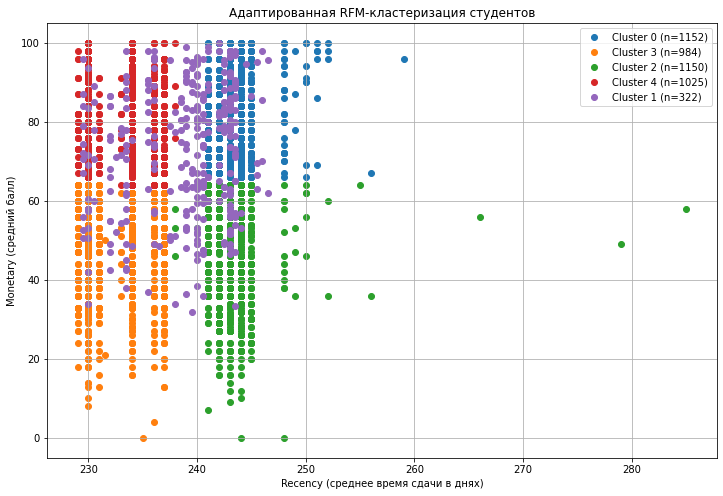


Границы кластеров:
        Recency        Frequency     Monetary       
            min    max       min max      min    max
Cluster                                             
0         241.0  259.0         1   1     66.0  100.0
1         229.5  246.5         2   2     32.0  100.0
2         238.0  285.0         1   1      0.0   64.0
3         229.0  237.0         1   1      0.0   64.0
4         229.0  238.0         1   1     64.0  100.0

Минимальная граница по Recency: 285.0 дней


In [24]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# 1. Фильтрация экзаменов и успешных попыток (score >= 40)
exams = assessments[assessments['assessment_type'] == 'Exam']
exam_results = pd.merge(student_assessment[student_assessment['score'] >= 0], 
                       exams, on='id_assessment')
merged_data = pd.merge(exam_results, student_registration,
                      on=['code_module', 'code_presentation', 'id_student'])

# 2. Корректный расчет RFM-метрик
def calculate_rfm(df):
    # Recency: среднее время сдачи экзамена от начала семестра (дни)
    r = df.groupby('id_student')['date_submitted'].mean().rename('Recency')
    
    # Frequency: количество завершенных курсов
    f = df.groupby('id_student')['code_module'].nunique().rename('Frequency')
    
    # Monetary: средний балл за экзамены
    m = df.groupby('id_student')['score'].mean().rename('Monetary')
    
    return pd.concat([r, f, m], axis=1)

rfm = calculate_rfm(merged_data).reset_index()

# 3. Нормализация данных
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# 4. Кластеризация K-means (5 кластеров)
kmeans = KMeans(n_clusters=5, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 5. Анализ кластеров
cluster_stats = rfm.groupby('Cluster').agg({
    'Recency': ['min', 'max', 'mean'],
    'Frequency': ['min', 'max', 'mean'],
    'Monetary': ['min', 'max', 'mean'],
    'id_student': 'count'
})

print("Статистика по кластерам:")
print(cluster_stats)

# 6. Визуализация
plt.figure(figsize=(12, 8))
for cluster in rfm['Cluster'].unique():
    cluster_data = rfm[rfm['Cluster'] == cluster]
    plt.scatter(cluster_data['Recency'], 
               cluster_data['Monetary'],
               label=f'Cluster {cluster} (n={len(cluster_data)})')

plt.xlabel('Recency (среднее время сдачи в днях)')
plt.ylabel('Monetary (средний балл)')
plt.title('Адаптированная RFM-кластеризация студентов')
plt.legend()
plt.grid(True)
plt.show()

# Границы кластеров
boundaries = rfm.groupby('Cluster').agg({
    'Recency': ['min', 'max'],
    'Frequency': ['min', 'max'],
    'Monetary': ['min', 'max']
})

print("\nГраницы кластеров:")
print(boundaries)

min_recency = rfm['Recency'].max()
print(f"\nМинимальная граница по Recency: {min_recency:.1f} дней")

In [21]:
cluster_stats = rfm.groupby('Cluster').agg({
    'Recency': ['min', 'max', 'mean'],
    'Frequency': ['min', 'max', 'mean'],
    'Monetary': ['min', 'max', 'mean']
})

In [22]:
cluster_stats

Recency                    Frequency          Monetary         \
            min    max        mean       min max mean      min    max   
Cluster                                                                 
0         229.0  238.0  233.243736         1   1    1     69.0  100.0   
1         238.0  285.0  243.181991         1   1    1     40.0   70.0   
2         229.5  246.5  238.989726         2   2    2     46.5  100.0   
3         229.0  238.0  232.737912         1   1    1     40.0   69.0   
4         238.0  259.0  243.321206         1   1    1     71.0  100.0   

                    
              mean  
Cluster             
0        83.124146  
1        55.845024  
2        75.238014  
3        54.664835  
4        85.371102

In [23]:
min_monetary = rfm['Monetary'].min()
print(f"Минимальная граница по Monetary: {min_monetary:.1f} баллов")

Минимальная граница по Monetary: 40.0 баллов


In [28]:
import pandas as pd

# Загрузка данных (предполагаем, что RFM-таблица уже готова)
# rfm = pd.DataFrame(...)  # Ваши данные

# 1. Расчет медианы Recency
median_recency = rfm['Recency'].median()

# 2. Присваивание R, F, M значений
rfm['R'] = np.where(rfm['Recency'] <= median_recency, 2, 1)
rfm['F'] = np.where(rfm['Frequency'] < 50, 1, 
                  np.where(rfm['Frequency'] < 100, 2, 3))
rfm['M'] = np.where(rfm['Monetary'] < 40, 1,
                  np.where(rfm['Monetary'] <= 80, 2, 3))

# 3. Фильтрация кластера 232
cluster_232 = rfm[(rfm['R'] == 2) & (rfm['F'] == 3) & (rfm['M'] == 2)]
count_232 = len(cluster_232)

print(f"Количество студентов в кластере 232: {count_232}")

KeyError: 'Recency'

In [29]:
# 1. Фильтрация экзаменов
exams = assessments[assessments['assessment_type'] == 'Exam']
exam_data = pd.merge(student_assessment, exams, on='id_assessment')
merged_data = pd.merge(exam_data, student_registration,
                     on=['code_module', 'code_presentation', 'id_student'])

# 2. Расчет метрик для каждого студента
student_stats = merged_data.groupby('id_student').agg({
    'date_submitted': 'mean',  # Среднее время сдачи
    'code_module': lambda x: x.nunique(),  # Количество курсов
    'score': 'mean',  # Средний балл
    'date_unregistration': lambda x: x.isna().all()  # Завершил все курсы
}).reset_index()

student_stats.columns = ['id_student', 'avg_submit_time', 'courses_count', 'avg_score', 'completed_all']

# 3. Расчет медианы времени сдачи
median_submit_time = student_stats['avg_submit_time'].median()

# 4. Фильтрация по критериям:
filtered_students = student_stats[
    (student_stats['avg_submit_time'] <= median_submit_time) &  # Время сдачи <= медианы
    (student_stats['completed_all']) &  # Завершил все курсы (100%)
    (student_stats['avg_score'] >= 40) &  # Средний балл ≥40
    (student_stats['avg_score'] <= 80)    # Средний балл ≤80
]

# 5. Сортировка по среднему баллу (по убыванию)
sorted_students = filtered_students.sort_values('avg_score', ascending=False)

# 6. Вывод результатов
print(f"Найдено студентов: {len(sorted_students)}")
print("\nОтсортированный список студентов:")
print(sorted_students[['id_student', 'avg_submit_time', 'avg_score', 'courses_count']].to_string(index=False))

Найдено студентов: 1573

Отсортированный список студентов:
 id_student  avg_submit_time  avg_score  courses_count
     626192            234.0       80.0              1
     549951            230.0       80.0              1
     623667            230.0       80.0              1
     507285            237.0       80.0              1
     623514            234.0       80.0              1
     509279            237.0       80.0              1
     623073            236.0       80.0              1
     621699            236.0       80.0              1
     517864            236.0       80.0              1
     618845            234.0       80.0              1
     520150            237.0       80.0              1
    2619496            234.0       80.0              1
     615437            234.0       80.0              1
     156783            237.0       80.0              1
     524396            229.0       80.0              1
     614176            234.0       80.0              1
     5